In [1]:
import numpy as np
import sys
from pathlib import Path

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)

from paths import *
sys.path.append(ML_Path)
from mllib import Utilities

import gc
from time import time

ut = Utilities()

In [2]:
# various matplotlib imports and settings
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

%matplotlib inline  

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# Visualize pairwise correlations in $\texttt{AbacusSummit}$
### Plot various quantities related to $\xi(s,\mu_s)$ and $P(k,\mu_k)$
#### See [$\texttt{AbacusSummit}$](https://abacussummit.readthedocs.io/en/latest/abacussummit.html) for raw data products
***

## Setup

### Files and folders

In [3]:
# unique string identifying the sample
# -- one of ['DESI-LRG2','Euclid-ELG','DESI-LRG2-AP-x3','DESI-LRG2-noAP-x3']
Sample = 'Euclid-ELG'

config_dict = {'DESI-LRG2': {'redshift':0.80,'Mmin':8e12,'phase':0,
                             'sample_root':'AbacusSummit/base_c000/'},
               'Euclid-ELG':{'redshift':1.10,'Mmin':1e12,'phase':1,
                             'sample_root':'AbacusSummit/base_c000/'}}

Redshift = config_dict[Sample]['redshift'] # [also 0.1,0.8 available for 'DESI-LRG2-x3/AP']

In [4]:
Plots_Dir = Base_Dir + 'plots/' + Sample + '/'
Path(Plots_Dir).mkdir(parents=True,exist_ok=True) # folder to store plots

Data_Dir = Base_Dir + 'data/AbacusSummit/base_c000/' + Sample + '/'

Include_Sig2Obs = True if 'noAP' not in Sample else False
# below should match what was used (safest not to change defaults)
L_Max = 3
N_Phase = 25 
# Mmin_dict = {'DESI-LRG2':8e12,
#              'DESI-LRG2-AP-x3':8e12 if Redshift > 0.5 else 1.25e13,
#              'DESI-LRG2-noAP-x3':8e12 if Redshift > 0.5 else 1.25e13}
# M_min = Mmin_dict[Sample] 
M_min = config_dict[Sample]['Mmin']

K_Min,K_Max = 0.02,0.05

File_Stem = 'xi_LMax{0:d}'.format(L_Max)
File_Stem_Real = 'xi'

File_Stem += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)
File_Stem_Real += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)

# Xi_File = Data_Dir + File_Stem + '.txt'
Scales_File = Data_Dir + File_Stem + '_scales.txt'
Xi_File_Colwise = Data_Dir + File_Stem + '_colwise.txt'
Xi_Phase_Stem = Data_Dir + File_Stem + '_ph'

# Xi_File_Real = Data_Dir + File_Stem_Real + '.txt'
Scales_File_Real = Data_Dir + File_Stem_Real + '_scales.txt'
Xi_File_Colwise_Real = Data_Dir + File_Stem_Real + '_colwise.txt'
Xi_Phase_Stem_Real = Data_Dir + File_Stem_Real + '_ph'

if Include_Sig2Obs:
    File_Stem_Pk = 'Pk_LMax{0:d}'.format(L_Max)
    File_Stem_Pk_Real = 'Pk'
    File_Stem_Sig2Obs = 'Sig2obs_LMax{0:d}_lgMmin{1:.2f}_z{2:.3f}'.format(L_Max,np.log10(M_min),Redshift)
    File_Stem_Pk += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)
    File_Stem_Pk_Real += '_lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift)
    Sig2Obs_File = Data_Dir + File_Stem_Sig2Obs + '.txt'
    Pk_File = Data_Dir + File_Stem_Pk + '.txt'
    Pk_File_Real = Data_Dir + File_Stem_Pk_Real + '.txt'

    Pk_Phase_Stem = Data_Dir + File_Stem_Pk + '_ph'
    Pk_Phase_Stem_Real = Data_Dir + File_Stem_Pk_Real + '_ph'
    Sig2Obs_Phase_Stem = Data_Dir + File_Stem_Sig2Obs + '_ph'


### Read data

In [5]:
print('Reading file: '+Xi_File_Colwise)
xi_cols = np.loadtxt(Xi_File_Colwise).T # expect s|(xi|err)_{ell=0,2,4}
scales = np.loadtxt(Scales_File)
if not np.allclose(xi_cols[0],scales):
    raise Exception('Mismatched scales in file: '+Xi_File_Colwise)
xi = np.zeros((L_Max,scales.size))
err_xi = np.zeros((L_Max,scales.size))
for L in range(L_Max):
    xi[L] = xi_cols[1+2*L]
    err_xi[L] = xi_cols[1+2*L+1]

print('Reading file: '+Xi_File_Colwise_Real)
xi_real = np.loadtxt(Xi_File_Colwise_Real).T # expect s| xi | err
scales_real = np.loadtxt(Scales_File_Real)
if not np.allclose(xi_real[0],scales_real):
    raise Exception('Mismatched scales in file: '+Xi_File_Colwise_Real)
err_xi_real = xi_real[2].copy()
xi_real = xi_real[1].copy()

if Include_Sig2Obs:
    print('Reading file: '+Sig2Obs_File)
    Sig2obs = np.loadtxt(Sig2Obs_File).T # expect Sig2 | err_Sig2
    err_Sig2obs = Sig2obs[1].copy()
    Sig2obs = Sig2obs[0].copy()

    print('Reading file: '+Pk_File)
    Pk = np.loadtxt(Pk_File).T # expect k|(Pk|err)_{ell=0,2,4}

    print('Reading file: '+Pk_File_Real)
    Pk_real = np.loadtxt(Pk_File_Real).T # expect k|(Pk|err)_{ell=0,2,4}


Reading file: ./data/AbacusSummit/base_c000/Euclid-ELG/xi_LMax3_lgMmin12.00_z1.100_colwise.txt
Reading file: ./data/AbacusSummit/base_c000/Euclid-ELG/xi_lgMmin12.00_z1.100_colwise.txt
Reading file: ./data/AbacusSummit/base_c000/Euclid-ELG/Sig2obs_LMax3_lgMmin12.00_z1.100.txt
Reading file: ./data/AbacusSummit/base_c000/Euclid-ELG/Pk_LMax3_lgMmin12.00_z1.100.txt
Reading file: ./data/AbacusSummit/base_c000/Euclid-ELG/Pk_lgMmin12.00_z1.100.txt


## Plots

In [8]:
Save_Fig = True

Writing to file: ./plots/Euclid-ELG/xi_LMax3_lgMmin12.00_z1.100.pdf


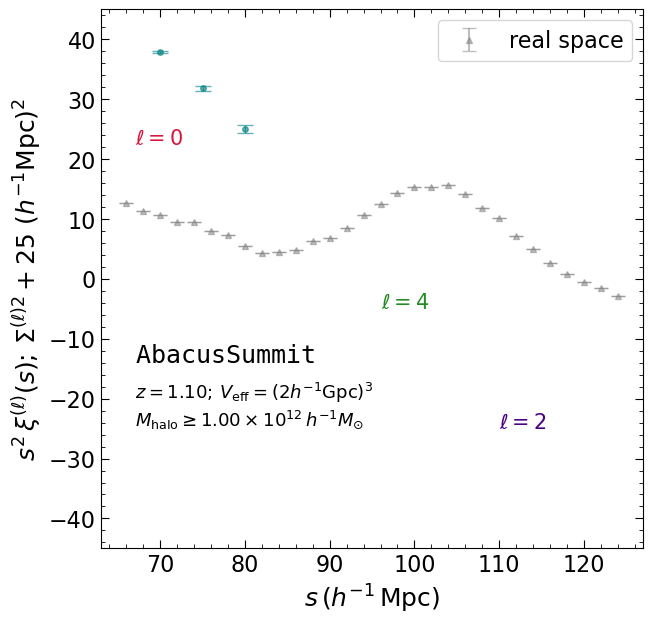

Writing to file: ./plots/Euclid-ELG/Pk_LMax3_lgMmin12.00_z1.100.pdf


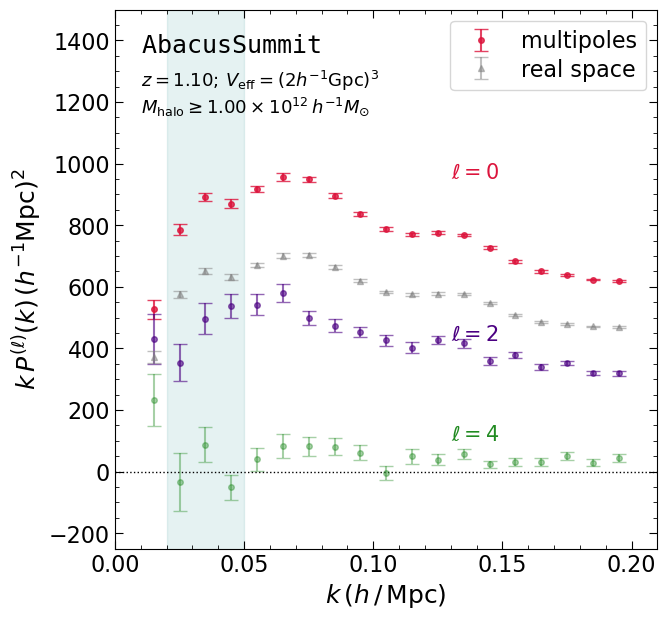

In [9]:
cols = ['crimson','indigo','forestgreen']
YFac = 1 if Sample != 'Euclid-ELG' else 2.0#1.5

if Sample[-2-len(str(N_Phase)):] == '-x{0:d}'.format(N_Phase):
    zV_text = '$z = {0:.2f}; \\, V_{{\\rm eff}} = {1:d}\\times(2h^{{-1}}{{\\rm Gpc}})^{{3}}$'.format(Redshift,N_Phase)
else:
    zV_text = '$z = {0:.2f}; \\, V_{{\\rm eff}} = (2h^{{-1}}{{\\rm Gpc}})^{{3}}$'.format(Redshift)

plt.figure(figsize=(7,7))
plt.xlabel('$s\\,(h^{{-1}}\\,{{\\rm Mpc}})$')
plt.xlim(63,127)
plt.ylim(-90/YFac,90/YFac)
ylabel = '$s^{{2}}\\,\\xi^{{(\\ell)}}(s)$'
if Include_Sig2Obs:
    off_vert = 50//YFac
    ylabel += '$;\\,\\Sigma^{{(\\ell)2}}+{0:.0f}$'.format(off_vert)
ylabel += '$\\,\\,(h^{{-1}}{{\\rm Mpc}})^{{2}}$'
plt.ylabel(ylabel)
# for L in range(L_Max):
#     data_label = 'multipoles' if L==0 else None
#     plt.errorbar(scales,scales**2*xi[L],yerr=scales**2*err_xi[L],
#                  c=cols[L],ls='none',capsize=5,marker='o',markersize=4,alpha=1-0.2*(L+1),label=data_label)
plt.errorbar(scales_real,scales_real**2*xi_real,yerr=scales_real**2*err_xi_real,
             c='gray',ls='none',capsize=5,marker='^',markersize=4,alpha=0.5,label='real space')

if Include_Sig2Obs:
    Sigx = np.linspace(70,70+5*(L_Max-1),L_Max).astype(int) 
    plt.errorbar(Sigx,Sig2obs+off_vert,yerr=err_Sig2obs,
                 marker='o',ls='none',c='teal',capsize=6,markersize=4,lw=1,alpha=0.6)

plt.text(67,(77-105)/YFac,'$\\tt{{AbacusSummit}}$',fontsize=FS)
plt.text(67,(65-105)/YFac,zV_text,fontsize=FS3)
mmin_expo = 12.0 if Redshift > 0.5 else 13.0
mmin_absc = M_min/10**mmin_expo
mmin_text = '$M_{{\\rm halo}} \\geq {0:.2f}\\times 10^{{{1:.0f}}}\\, h^{{-1}}M_{{\\odot}}$'.format(mmin_absc,mmin_expo)
plt.text(67,(56-105)/YFac,mmin_text,fontsize=FS3)

plt.text(67,45/YFac,'$\ell = 0$',fontsize=FS2,c=cols[0])
if L_Max > 1:
    plt.text(110,-50/YFac,'$\ell = 2$',fontsize=FS2,c=cols[1])
    if L_Max == 3:
        plt.text(96,-10/YFac,'$\ell = 4$',fontsize=FS2,c=cols[2])

plt.legend(loc='upper right')
plt.minorticks_on()
if Save_Fig:
    Xi_Plot_File = Plots_Dir + File_Stem + '.pdf'
    print('Writing to file: '+Xi_Plot_File)
    plt.savefig(Xi_Plot_File,bbox_inches='tight')
plt.show()

if Include_Sig2Obs:
    YFac = 1 if Sample != 'Euclid-ELG' else 2.0
    plt.figure(figsize=(7,7))
    plt.xlabel('$k\\,(h\\,/\\,{{\\rm Mpc}})$')
    plt.xlim(0,0.21)
    plt.ylim(-500/YFac,3000/YFac)
    ylabel = '$k\\,P^{{(\\ell)}}(k) \\,(h^{{-1}}{{\\rm Mpc}})^{{2}}$'
    plt.ylabel(ylabel)
    for L in range(L_Max):
        data_label = 'multipoles' if L==0 else None
        plt.errorbar(Pk[0],Pk[0]*Pk[2*L+1],yerr=Pk[0]*Pk[2*L+2],
                     c=cols[L],ls='none',capsize=5,marker='o',markersize=4,alpha=1-0.2*(L+1),label=data_label)
    # khfac = 1+2*0.2/3+0.2**2/5
    plt.errorbar(Pk_real[0],Pk_real[0]*Pk_real[1],yerr=Pk_real[0]*Pk_real[2],
                 c='gray',ls='none',capsize=5,marker='^',markersize=4,alpha=0.5,label='real space')
    plt.axhline(0.0,c='k',ls=':',lw=1)
    yvals = np.linspace(-5000/YFac,5000/YFac,10)
    plt.fill_betweenx(yvals,K_Max*np.ones_like(yvals),K_Min*np.ones_like(yvals),color='teal',alpha=0.1)
    plt.legend(loc='upper right')
    plt.minorticks_on()
    
    plt.text(0.01,2720/YFac,'$\\tt{{AbacusSummit}}$',fontsize=FS)
    plt.text(0.01,2500/YFac,zV_text,fontsize=FS3)
    mmin_expo = 12.0 if Redshift > 0.5 else 13.0
    mmin_absc = M_min/10**mmin_expo
    mmin_text = '$M_{{\\rm halo}} \\geq {0:.2f}\\times 10^{{{1:.0f}}}\\, h^{{-1}}M_{{\\odot}}$'.format(mmin_absc,mmin_expo)
    plt.text(0.01,2330/YFac,mmin_text,fontsize=FS3)
    
    plt.text(0.13,1900/YFac,'$\ell = 0$',fontsize=FS2,c=cols[0])
    if L_Max > 1:
        plt.text(0.13,850/YFac,'$\ell = 2$',fontsize=FS2,c=cols[1])
        if L_Max == 3:
            plt.text(0.13,200/YFac,'$\ell = 4$',fontsize=FS2,c=cols[2])
    
    if Save_Fig:
        Pk_Plot_File = Plots_Dir + File_Stem_Pk + '.pdf'
        print('Writing to file: '+Pk_Plot_File)
        plt.savefig(Pk_Plot_File,bbox_inches='tight')
    plt.show()
